# Global forecasting: manually selected ML and all deep-learning models

Each input CSV is a **long-format panel**: 100 related series × 500 aligned observations = 50,000 rows.

- XGBRandomForest is the ML family selected from the manual-series validation comparison. Its hyperparameters are tuned separately on each global validation panel using one pooled model per deterministic series block—not one model or Optuna study per series. Test reloads those frozen block-level configurations.
- DL evaluates all 15 NeuralForecast architectures. Validation runs the common Auto/Optuna protocol on observations 1–480 and forecasts 481–490; test freezes every resolved configuration, refits on observations 1–490, and forecasts 491–500.
- The global exercise contains the three signal-bearing synthetic panels generated for the benchmark.

In [7]:
from pathlib import Path
import json
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'thesis').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
THESIS_DIR = REPO_ROOT / 'thesis'
if str(THESIS_DIR) not in sys.path:
    sys.path.insert(0, str(THESIS_DIR))

from dl_evaluation import DL_MODEL_NAMES, load_dl_configs
from global_evaluation import (
    GLOBAL_DL_CATEGORIES,
    GLOBAL_SYNTHETIC_DATASETS,
    aggregate_global_metrics,
    configure_global_dl_models,
    evaluate_global_dl,
    evaluate_global_ml,
    fit_and_evaluation_frames,
    global_dl_record,
    load_global_panel,
    panel_audit,
    selection_summary,
    split_global_panel,
    tune_global_xgb_random_forest,
)
from reporting import (
    dataset_descriptor, figure_path, metadata_for,
    publication_latex, save_matplotlib_figure,
)
from runtime import CPU_THREADS

try:
    import torch
    if torch.cuda.is_available():
        torch.set_float32_matmul_precision('high')
except ImportError:
    pass

## Run controls

`ML_PARTITION_SIZE=100` means one genuinely global tree model and one Optuna study for all 100 series in a panel. A smaller value tunes and fits one pooled model per deterministic block, never one model per series. XGBRandomForest is fixed as the family selected from the manual validation results; only its global-panel hyperparameters are tuned here. Every DL architecture receives the same trial count, startup count, input-size candidates, and step ceiling.

In [18]:
SEED = 67
EVALUATION_SPLIT = 'test'  # run validation first, then test fresh
REUSE_SAVED_VALIDATION_CONFIGS = True
ACTIVE_DATASETS = list(GLOBAL_SYNTHETIC_DATASETS)

RUN_ML = True
RUN_DL = True
GLOBAL_ML_REPRESENTATIONS = {
    'autoregressive': 'Original',
    'pseudo_periodic': 'Original',
    'sinusoidal_trend_noise': 'AutoStationary',
}
GLOBAL_ML_MODEL = 'XGBRandomForest'
GLOBAL_ML_LAGS = {
    'autoregressive': [1, 2, 3, 4, 8],
    'pseudo_periodic': [1, 2, 3, 4, 8, 12],
    'sinusoidal_trend_noise': [1, 2, 3, 4, 8, 12],
}
ML_PARTITION_SIZE = 100
ML_OPTUNA_TRIALS = 25
ML_N_JOBS = CPU_THREADS

DL_MODELS = list(DL_MODEL_NAMES)
DL_CONFIG_DIR = THESIS_DIR / 'model_configs' / 'dl'
ML_SELECTION_PATH = THESIS_DIR / 'model_configs' / 'global_ml_validation_configs.json'
DL_SELECTION_PATH = THESIS_DIR / 'model_configs' / 'global_dl_validation_configs.json'
DL_NUM_SAMPLES = 4
DL_STARTUP_TRIALS = 2
DL_MAX_STEPS = 1000
DL_INTERNAL_VAL_SIZE = 10
DL_INPUT_SIZE_CANDIDATES = [10, 20, 40]

SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

METRICS_DIR = THESIS_DIR / 'metrics'
RESULTS_DIR = THESIS_DIR / 'results'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if EVALUATION_SPLIT not in {'validation', 'test'}:
    raise ValueError("EVALUATION_SPLIT must be 'validation' or 'test'")
unknown = set(ACTIVE_DATASETS) - set(GLOBAL_SYNTHETIC_DATASETS)
if unknown:
    raise ValueError(f'Unknown datasets: {sorted(unknown)}')
if RUN_ML and set(ACTIVE_DATASETS) - set(GLOBAL_ML_LAGS):
    raise ValueError('Declare global ML lags for every active DGP')
if RUN_ML and GLOBAL_ML_MODEL != 'XGBRandomForest':
    raise ValueError('The manual validation comparison selected XGBRandomForest')
if set(DL_MODELS) != set(DL_MODEL_NAMES):
    raise ValueError('The global benchmark must retain all 15 DL architectures')

## Data and transferred-model audit

This cell makes the panel dimensions and predeclared protocol visible before any expensive fit begins.

In [19]:
audit_rows = []
for dataset_name in ACTIVE_DATASETS:
    panel, config = load_global_panel(dataset_name)
    splits = split_global_panel(panel, config['horizon'])
    audit = panel_audit(panel, splits)
    audit.insert(0, 'DGP', dataset_name)
    audit_rows.append(audit)

data_audit = pd.concat(audit_rows, ignore_index=True)
display(data_audit)
display(selection_summary(
    ACTIVE_DATASETS, run_ml=False, dl_models=DL_MODELS,
))
if RUN_ML:
    display(pd.DataFrame([
        {
            'DGP': name, 'Family': 'ML',
            'Target': GLOBAL_ML_REPRESENTATIONS[name],
            'Model': GLOBAL_ML_MODEL,
            'Selection basis': 'Manual-series validation family winner; global-panel Optuna',
        }
        for name in ACTIVE_DATASETS
    ]))

,DGP,Rows,Series,Time steps per series,Balanced,Train steps,Validation steps,Test steps
0,autoregressive,50000,100,500,True,480,10,10
1,pseudo_periodic,50000,100,500,True,480,10,10
2,sinusoidal_trend_noise,50000,100,500,True,480,10,10


,DGP,Family,Target,Model,DL category,Selection basis
0,autoregressive,DL,Original,AutoRNN,Recurrent,Global validation (all architectures)
1,autoregressive,DL,Original,AutoLSTM,Recurrent,Global validation (all architectures)
2,autoregressive,DL,Original,AutoGRU,Recurrent,Global validation (all architectures)
3,autoregressive,DL,Original,AutoVanillaTransformer,Attention,Global validation (all architectures)
4,autoregressive,DL,Original,AutoAutoformer,Attention,Global validation (all architectures)
5,autoregressive,DL,Original,AutoPatchTST,Attention,Global validation (all architectures)
6,autoregressive,DL,Original,AutoiTransformer,Attention,Global validation (all architectures)
7,autoregressive,DL,Original,AutoTFT,Attention,Global validation (all architectures)
8,autoregressive,DL,Original,AutoTimesNet,Convolutional,Global validation (all architectures)
9,autoregressive,DL,Original,AutoNLinear,Linear,Global validation (all architectures)


,DGP,Family,Target,Model,Selection basis
0,autoregressive,ML,Original,XGBRandomForest,Manual-series validation family winner; global...
1,pseudo_periodic,ML,Original,XGBRandomForest,Manual-series validation family winner; global...
2,sinusoidal_trend_noise,ML,AutoStationary,XGBRandomForest,Manual-series validation family winner; global...


## Global fits

No target-based weighting, clustering, or series-ID feature is used. XGBRandomForest was selected as the ML family using only the manual-series validation results. Here, one pooled Optuna study is run per 100-series panel: AR(1) and pseudo-periodic targets use Original, while the sinusoid with trend and noise uses AutoStationary. Validation saves the panel-specific tree configuration and test only refits it on train plus validation. All 15 DL architectures follow the equivalent validation/frozen-test separation.

In [20]:
all_results = {}
per_series_metrics = []
aggregate_tables = []
timing_tables = []
run_start = time.perf_counter()

base_dl_configs = load_dl_configs(DL_CONFIG_DIR, DL_MODELS)
global_dl_configs = configure_global_dl_models(
    base_dl_configs,
    input_size_candidates=DL_INPUT_SIZE_CANDIDATES,
    num_samples=DL_NUM_SAMPLES,
    startup_trials=DL_STARTUP_TRIALS,
    max_steps=DL_MAX_STEPS,
    seed=SEED,
)
expected_dl_protocol = {
    'seed': SEED,
    'models': DL_MODELS,
    'num_samples': DL_NUM_SAMPLES,
    'startup_trials': DL_STARTUP_TRIALS,
    'max_steps': DL_MAX_STEPS,
    'internal_val_size': DL_INTERNAL_VAL_SIZE,
    'input_size_candidates': DL_INPUT_SIZE_CANDIDATES,
}
expected_ml_protocol = {
    'seed': SEED,
    'model': GLOBAL_ML_MODEL,
    'n_trials': ML_OPTUNA_TRIALS,
    'partition_size': ML_PARTITION_SIZE,
    'representations': GLOBAL_ML_REPRESENTATIONS,
    'lags': GLOBAL_ML_LAGS,
}
ml_config_store = {'protocol': expected_ml_protocol, 'per_dataset': {}}
if RUN_ML and (
    EVALUATION_SPLIT == 'test'
    or (REUSE_SAVED_VALIDATION_CONFIGS and ML_SELECTION_PATH.exists())
):
    if not ML_SELECTION_PATH.exists():
        raise FileNotFoundError('Run global ML validation before the test benchmark')
    ml_config_store = json.loads(ML_SELECTION_PATH.read_text(encoding='utf-8'))
    if ml_config_store.get('protocol') != expected_ml_protocol:
        raise ValueError('Saved global ML configurations use a different protocol')
dl_config_store = {'protocol': expected_dl_protocol, 'per_dataset': {}}
if (
    EVALUATION_SPLIT == 'test'
    or (REUSE_SAVED_VALIDATION_CONFIGS and DL_SELECTION_PATH.exists())
):
    if not DL_SELECTION_PATH.exists():
        raise FileNotFoundError('Run global validation before the test benchmark')
    dl_config_store = json.loads(DL_SELECTION_PATH.read_text(encoding='utf-8'))
    if dl_config_store.get('protocol') != expected_dl_protocol:
        raise ValueError('Saved global DL configurations use a different protocol')

for dataset_index, dataset_name in enumerate(ACTIVE_DATASETS, start=1):
    dataset_start = time.perf_counter()
    panel, config = load_global_panel(dataset_name)
    splits = split_global_panel(panel, config['horizon'])
    fit_df, eval_df = fit_and_evaluation_frames(splits, EVALUATION_SPLIT)
    combined_results = eval_df[['unique_id', 'ds', 'y']].copy()
    forecast_columns = []

    print(
        f'[{dataset_index}/{len(ACTIVE_DATASETS)}] {dataset_descriptor(dataset_name)}: '
        f'{fit_df.unique_id.nunique()} series x '
        f'{fit_df.groupby("unique_id").size().iloc[0]} fitting steps'
    )

    if RUN_ML:
        transformation = GLOBAL_ML_REPRESENTATIONS[dataset_name]
        reuse_ml_validation = (
            EVALUATION_SPLIT == 'validation'
            and REUSE_SAVED_VALIDATION_CONFIGS
            and dataset_name in ml_config_store.get('per_dataset', {})
        )
        if EVALUATION_SPLIT == 'validation' and not reuse_ml_validation:
            record = tune_global_xgb_random_forest(
                fit_df, eval_df,
                transformation=transformation,
                seasonality=config['seasonality'],
                lags=GLOBAL_ML_LAGS[dataset_name],
                partition_size=ML_PARTITION_SIZE,
                freq=config['freq'], n_trials=ML_OPTUNA_TRIALS,
                seed=SEED, n_jobs=ML_N_JOBS,
            )
            ml_config_store['per_dataset'][dataset_name] = record
            ML_SELECTION_PATH.parent.mkdir(parents=True, exist_ok=True)
            ML_SELECTION_PATH.write_text(
                json.dumps(ml_config_store, indent=2), encoding='utf-8'
            )
        else:
            try:
                record = ml_config_store['per_dataset'][dataset_name]
            except KeyError as error:
                raise KeyError(
                    f'Missing global ML validation configuration for {dataset_name}'
                ) from error
        print(f'  ML {transformation}: {record["base_model"]}')
        results, metrics, timing = evaluate_global_ml(
            fit_df=fit_df, eval_df=eval_df, record=record,
            transformation=transformation, seasonality=config['seasonality'],
            partition_size=ML_PARTITION_SIZE, freq=config['freq'],
            seed=SEED, n_jobs=ML_N_JOBS,
        )
        new_columns = [c for c in results if c not in {'unique_id', 'ds', 'y'}]
        combined_results = combined_results.merge(
                results[['unique_id', 'ds'] + new_columns],
                on=['unique_id', 'ds'], how='left', validate='one_to_one',
            )
        forecast_columns.extend(new_columns)
        metrics.insert(0, 'DGP', dataset_name)
        metrics.insert(1, 'Split', EVALUATION_SPLIT)
        timing.insert(0, 'DGP', dataset_name)
        timing.insert(1, 'Split', EVALUATION_SPLIT)
        per_series_metrics.append(metrics)
        aggregate_tables.append(aggregate_global_metrics(
                metrics, dataset_name, EVALUATION_SPLIT
        ))
        timing_tables.append(timing)

    if RUN_DL:
        saved_records = dl_config_store['per_dataset'].setdefault(dataset_name, {})
        for model_index, model_name in enumerate(DL_MODELS, start=1):
            reuse_dl_validation = (
                EVALUATION_SPLIT == 'validation'
                and REUSE_SAVED_VALIDATION_CONFIGS
                and model_name in saved_records
            )
            if EVALUATION_SPLIT == 'validation' and not reuse_dl_validation:
                dl_record = {
                    'base_model': model_name,
                    'config': global_dl_configs[model_name],
                    'dl_category': GLOBAL_DL_CATEGORIES[model_name],
                    'selection_note': 'Global-panel validation architecture',
                }
                tune_model, inner_val_size = True, DL_INTERNAL_VAL_SIZE
            else:
                if model_name not in saved_records:
                    raise KeyError(f'Missing validation configuration for {dataset_name}/{model_name}')
                dl_record = saved_records[model_name]
                tune_model, inner_val_size = False, 0
            print(
                f'  DL {model_index}/{len(DL_MODELS)} '
                f'{GLOBAL_DL_CATEGORIES[model_name]}: {model_name}'
            )
            results, metrics, timing, resolved = evaluate_global_dl(
                fit_df=fit_df, eval_df=eval_df, record=dl_record,
                freq=config['freq'], tune=tune_model,
                internal_val_size=inner_val_size,
                progress_label=f'{dataset_name} | global DL {model_index}/{len(DL_MODELS)}',
            )
            if EVALUATION_SPLIT == 'validation' and not reuse_dl_validation:
                saved_records[model_name] = global_dl_record(
                    model_name, resolved[model_name],
                    source='Global-panel validation with Optuna',
                    validation_rmse=metrics['rmse'].mean(),
                )
                DL_SELECTION_PATH.parent.mkdir(parents=True, exist_ok=True)
                DL_SELECTION_PATH.write_text(
                    json.dumps(dl_config_store, indent=2), encoding='utf-8'
                )
            new_columns = [c for c in results if c not in {'unique_id', 'ds', 'y'}]
            combined_results = combined_results.merge(
                results[['unique_id', 'ds'] + new_columns],
                on=['unique_id', 'ds'], how='left', validate='one_to_one',
            )
            forecast_columns.extend(new_columns)
            metrics.insert(0, 'DGP', dataset_name)
            metrics.insert(1, 'Split', EVALUATION_SPLIT)
            timing.insert(0, 'DGP', dataset_name)
            timing.insert(1, 'Split', EVALUATION_SPLIT)
            per_series_metrics.append(metrics)
            aggregate_tables.append(aggregate_global_metrics(
                metrics, dataset_name, EVALUATION_SPLIT
            ))
            timing_tables.append(timing)

    all_results[dataset_name] = {
        'panel': panel, 'fit_df': fit_df, 'eval_df': eval_df,
        'results': combined_results, 'forecast_columns': forecast_columns,
    }
    prediction_path = METRICS_DIR / (
        f'global_models_predictions_{EVALUATION_SPLIT}_{dataset_name}.csv'
    )
    combined_results.to_csv(prediction_path, index=False)
    print(f'  forecast checkpoint: {prediction_path}')
    print(f'  completed in {(time.perf_counter() - dataset_start) / 60:.1f} minutes')

print(f'Total notebook fitting time: {(time.perf_counter() - run_start) / 60:.1f} minutes')

[1/3] Global Synthetic AR(1); Generated regular step; Simulated value; Not applicable: 100 series x 490 fitting steps
  ML Original: XGBRandomForest


Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  DL 1/15 Recurrent: AutoRNN
autoregressive | global DL 1/15 | fixed refit: model 1/1 (AutoRNN) started


`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


autoregressive | global DL 1/15 | fixed refit: model 1/1 (AutoRNN) completed in 11s | phase elapsed 11s | phase ETA 0s
  DL 2/15 Recurrent: AutoLSTM
autoregressive | global DL 2/15 | fixed refit: model 1/1 (AutoLSTM) started


...

sinusoidal_trend_noise | global DL 13/15 | fixed refit: model 1/1 (AutoNBEATS) completed in 16s | phase elapsed 16s | phase ETA 0s
  DL 14/15 Basis expansion: AutoNHITS
sinusoidal_trend_noise | global DL 14/15 | fixed refit: model 1/1 (AutoNHITS) started


`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


sinusoidal_trend_noise | global DL 14/15 | fixed refit: model 1/1 (AutoNHITS) completed in 16s | phase elapsed 16s | phase ETA 0s
  DL 15/15 KAN: AutoKAN
sinusoidal_trend_noise | global DL 15/15 | fixed refit: model 1/1 (AutoKAN) started


`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


sinusoidal_trend_noise | global DL 15/15 | fixed refit: model 1/1 (AutoKAN) completed in 14s | phase elapsed 14s | phase ETA 0s
  forecast checkpoint: c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\global_models_predictions_test_sinusoidal_trend_noise.csv
  completed in 5.6 minutes
Total notebook fitting time: 16.8 minutes


## Tables and portable outputs

Metrics are computed per series over the complete ten-step path, then averaged equally across the 100 series. Validation and test use separate filenames, so a test run does not overwrite validation evidence.

In [21]:
global_per_series_metrics = pd.concat(per_series_metrics, ignore_index=True)
global_aggregate_metrics = pd.concat(aggregate_tables, ignore_index=True)
global_timing = pd.concat(timing_tables, ignore_index=True)

global_aggregate_metrics['DGP'] = global_aggregate_metrics['DGP'].map(
    lambda name: dataset_descriptor(name)
)
global_aggregate_metrics = global_aggregate_metrics.sort_values(
    ['DGP', 'Mean RMSE', 'Model Family', 'Target Transformation']
).reset_index(drop=True)
display(global_aggregate_metrics)
display(global_timing)

metric_path = METRICS_DIR / f'global_models_metrics_{EVALUATION_SPLIT}.csv'
series_path = METRICS_DIR / f'global_models_per_series_{EVALUATION_SPLIT}.csv'
timing_path = METRICS_DIR / f'global_models_timing_{EVALUATION_SPLIT}.csv'
latex_path = RESULTS_DIR / f'global_models_results_{EVALUATION_SPLIT}.tex'

global_aggregate_metrics.to_csv(metric_path, index=False)
global_per_series_metrics.to_csv(series_path, index=False)
global_timing.to_csv(timing_path, index=False)
for dataset_name, data in all_results.items():
    prediction_path = METRICS_DIR / (
        f'global_models_predictions_{EVALUATION_SPLIT}_{dataset_name}.csv'
    )
    data['results'].to_csv(prediction_path, index=False)
latex_path.write_text(publication_latex(
    global_aggregate_metrics,
    float_format=lambda value: f'{value:.4f}',
    caption=(
        f'Global synthetic {EVALUATION_SPLIT} performance, averaged equally '
        'across 100 series for each data-generating process.'
    ),
    label=f'tab:global-models-{EVALUATION_SPLIT}',
), encoding='utf-8')
print(metric_path)
print(series_path)
print(timing_path)
print(latex_path)

,DGP,Split,Number of Series,Model Family,Model,Base Model,Target Transformation,Mean MAE,Mean MSE,Mean RMSE,Mean Forecast Bias,DL Category
0,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoGRU,AutoGRU,Original,1.214104,2.293126,1.435856,31.309296,Recurrent
1,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoLSTM,AutoLSTM,Original,1.214292,2.294832,1.436401,33.098723,Recurrent
2,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoRNN,AutoRNN,Original,1.214947,2.297274,1.436509,34.463874,Recurrent
3,Global Synthetic AR(1); Generated regular step...,test,100,ML,Global_XGBRandomForest,XGBRandomForest,Original,1.218029,2.288353,1.439651,49.602621,NaN
4,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoPatchTST,AutoPatchTST,Original,1.289765,2.589239,1.516774,-17.150701,Attention
5,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoTFT,AutoTFT,Original,1.308366,2.664493,1.533830,8.368051,Attention
6,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoKAN,AutoKAN,Original,1.310845,2.707353,1.535768,-45.427544,KAN
7,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoTimesNet,AutoTimesNet,Original,1.311294,2.729910,1.536835,-40.309465,Convolutional
8,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoNHITS,AutoNHITS,Original,1.310098,2.700422,1.537685,-52.477673,Basis expansion
9,Global Synthetic AR(1); Generated regular step...,test,100,DL,AutoNBEATS,AutoNBEATS,Original,1.314689,2.726212,1.542445,-54.464135,Basis expansion


,DGP,Split,Model Family,Model,Target Transformation,Partition,Series in Partition,Preprocessing Time,Tuning Time,Training Time,Forecast Time,Best Iteration,Time Elapsed,DL Category
0,autoregressive,test,ML,Global_XGBRandomForest,Original,1,100,0.539736,53.494819,0.925075,1.398248,None,2.863060,NaN
1,autoregressive,test,DL,AutoRNN,Original,1,100,0.000000,0.000000,10.404953,0.240361,NaN,10.645314,Recurrent
2,autoregressive,test,DL,AutoLSTM,Original,1,100,0.000000,0.000000,12.643463,0.230967,NaN,12.874430,Recurrent
3,autoregressive,test,DL,AutoGRU,Original,1,100,0.000000,0.000000,12.389502,0.207012,NaN,12.596514,Recurrent
4,autoregressive,test,DL,AutoVanillaTransformer,Original,1,100,0.000000,0.000000,39.775147,0.165553,NaN,39.940700,Attention
5,autoregressive,test,DL,AutoAutoformer,Original,1,100,0.000000,0.000000,53.151697,0.170734,NaN,53.322431,Attention
6,autoregressive,test,DL,AutoPatchTST,Original,1,100,0.000000,0.000000,25.374569,0.146346,NaN,25.520914,Attention
7,autoregressive,test,DL,AutoiTransformer,Original,1,100,0.000000,0.000000,33.621818,0.131398,NaN,33.753216,Attention
8,autoregressive,test,DL,AutoTFT,Original,1,100,0.000000,0.000000,28.823769,0.135271,NaN,28.959040,Attention
9,autoregressive,test,DL,AutoTimesNet,Original,1,100,0.000000,0.000000,26.436652,0.159219,NaN,26.595872,Convolutional


c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\global_models_metrics_test.csv
c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\global_models_per_series_test.csv
c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\global_models_timing_test.csv
c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\results\global_models_results_test.tex


## Representative forecasts

Only the first series of each DGP is plotted. When ML is enabled, its declared target tracks receive a separate figure; the DL figure compares all 15 architectures. Only the final 20 fitting observations are shown before the ten-step forecast boundary; the metric tables still use all 100 series and the complete evaluation horizon.

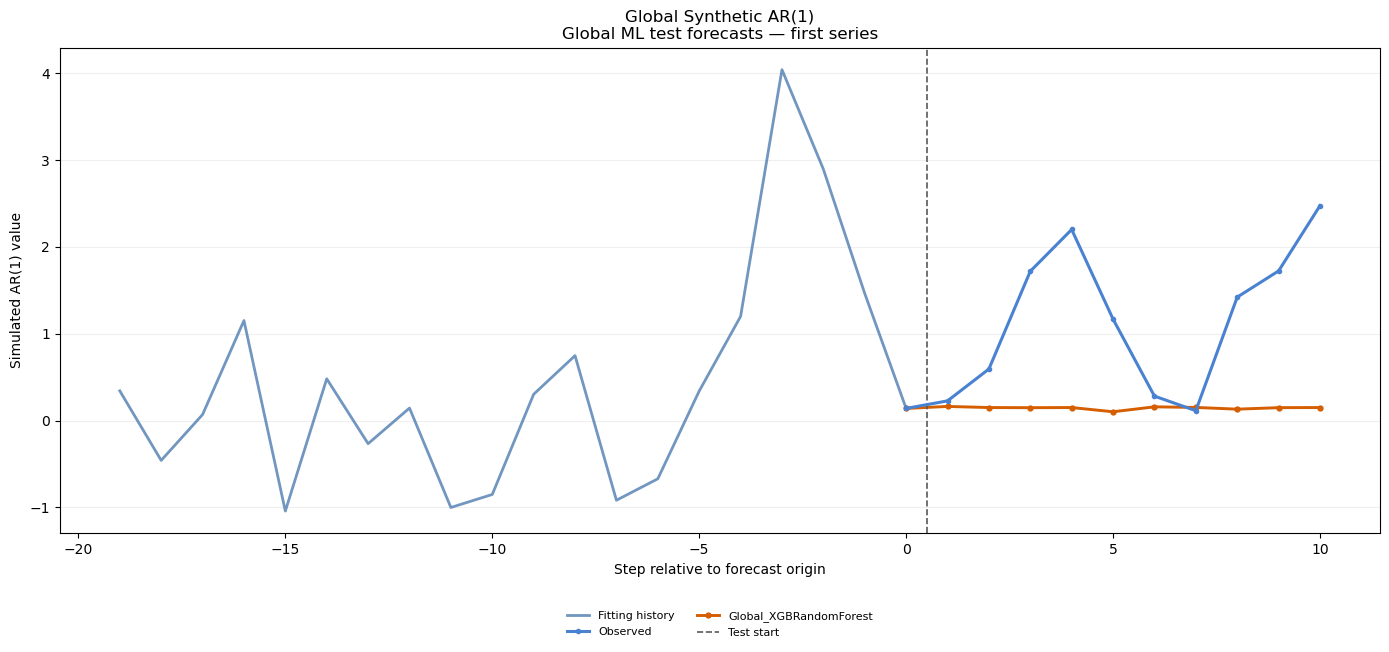

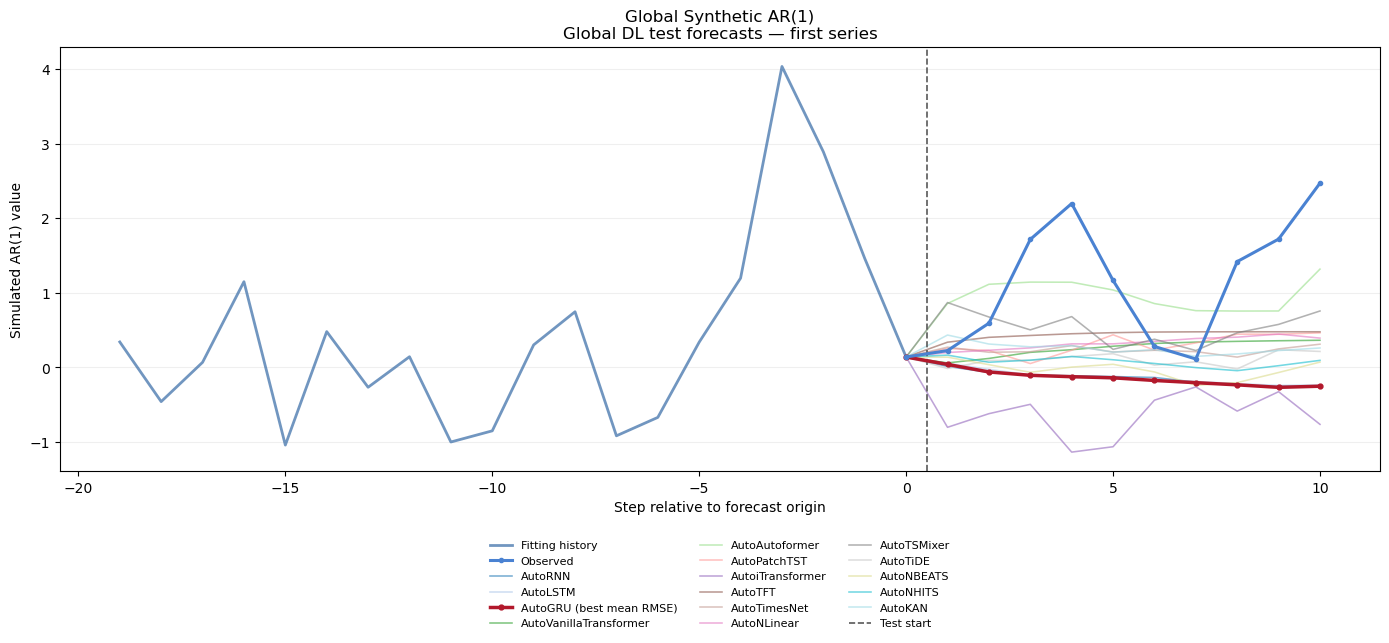

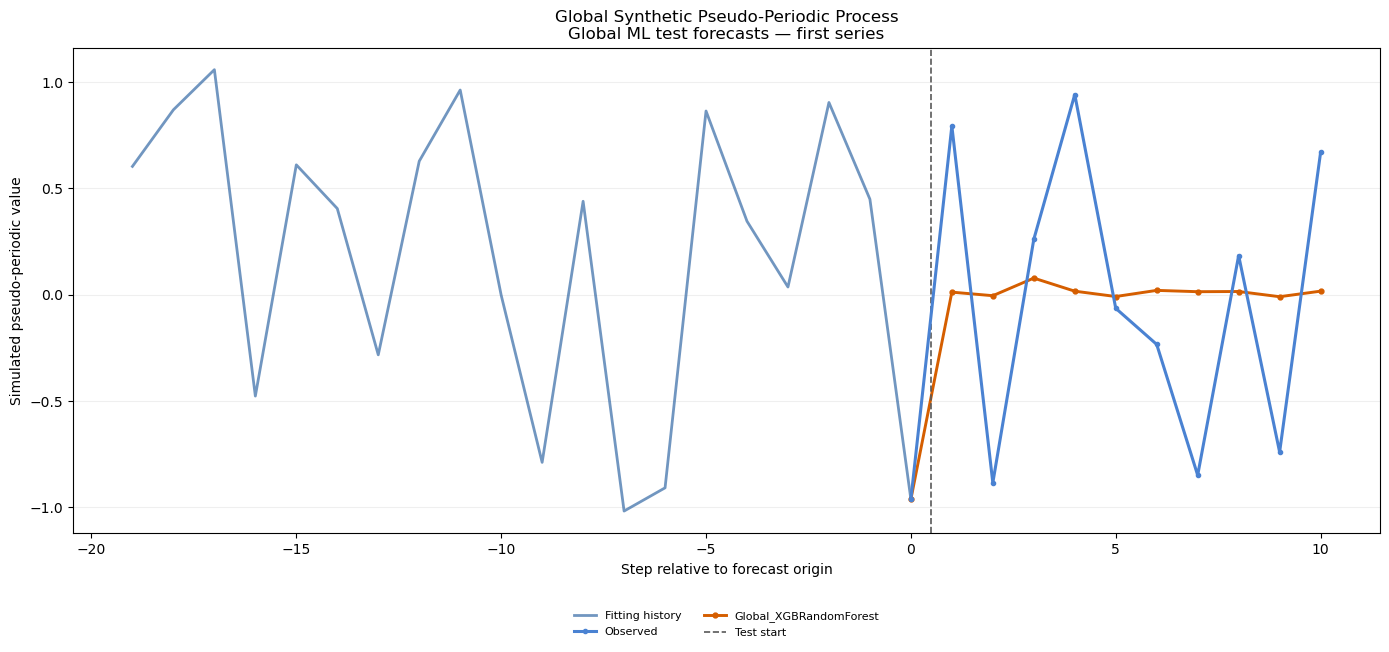

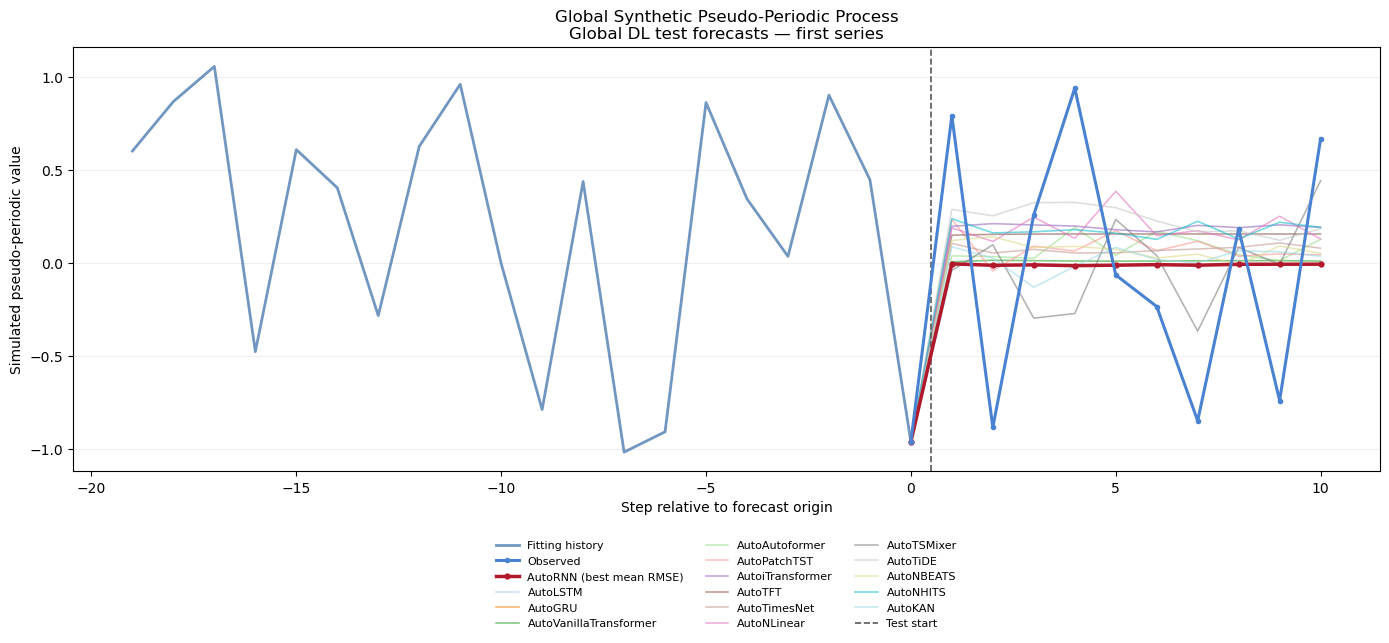

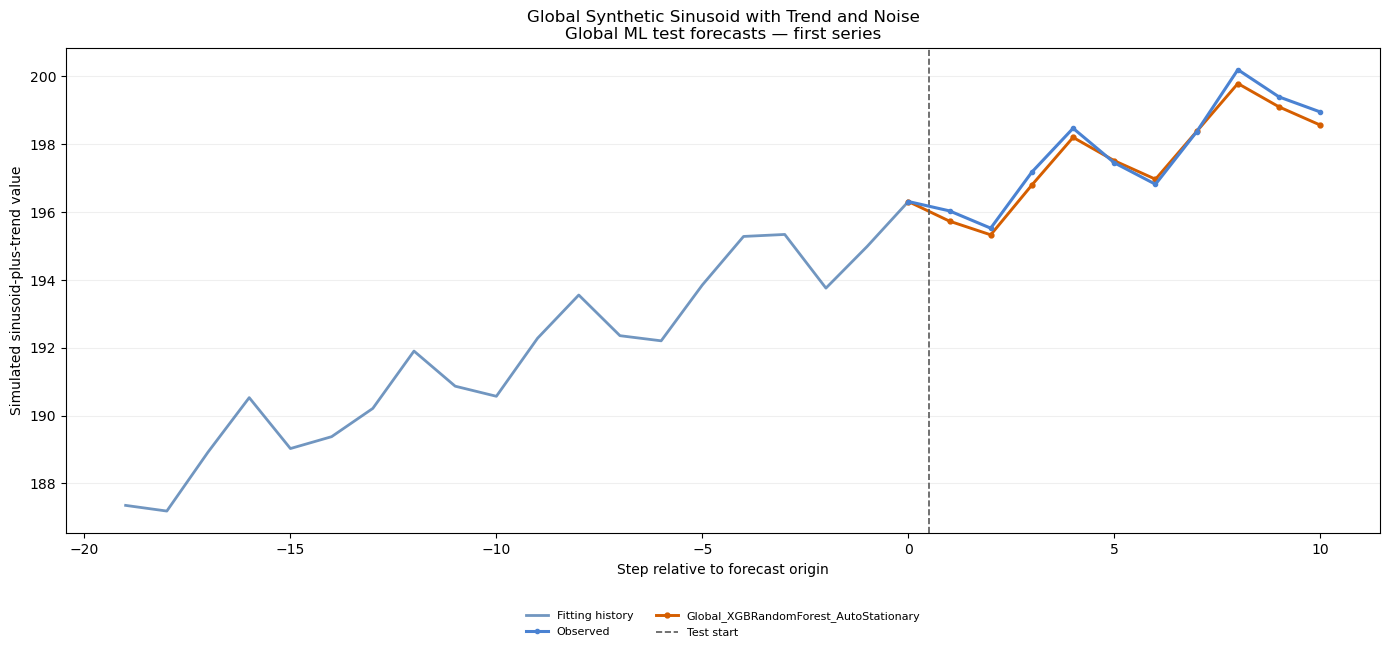

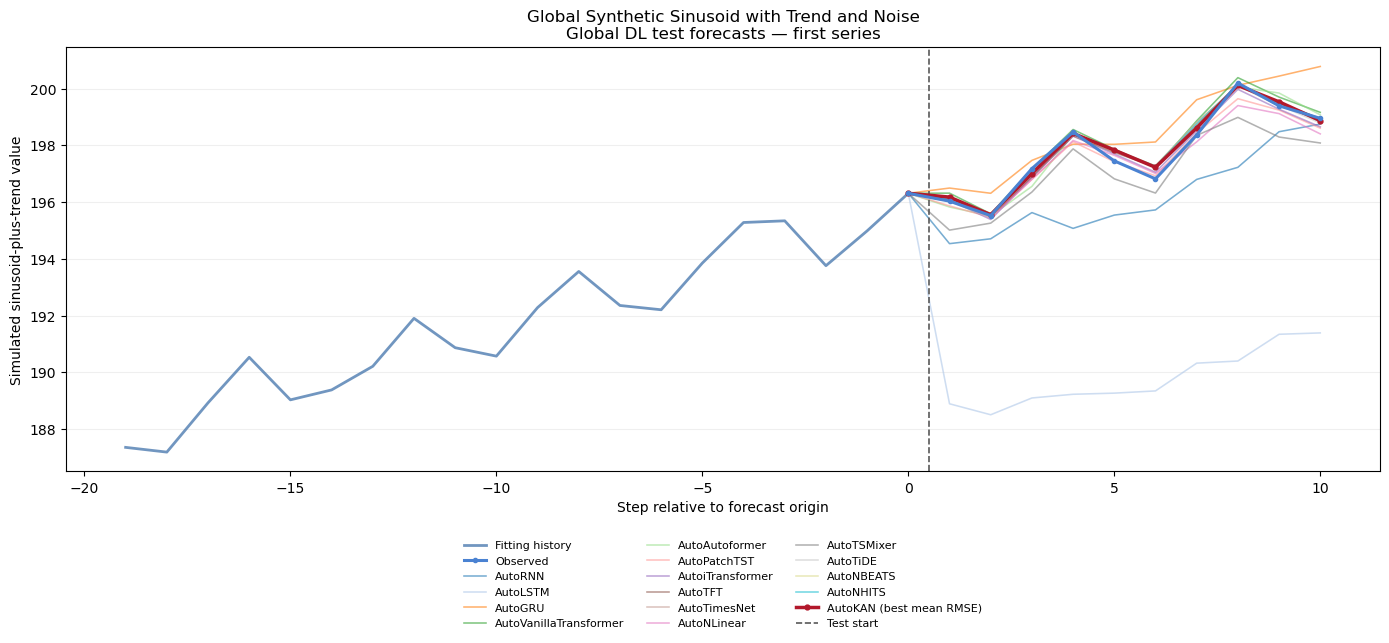

In [22]:
PLOT_HISTORY_STEPS = 20

def plot_global_family(history, forecast, columns, dataset_name, family, best_column=None):
    metadata = metadata_for(dataset_name)
    fig, axis = plt.subplots(figsize=(14, 7.5))
    history_steps = np.arange(-len(history) + 1, 1)
    forecast_steps = np.arange(1, len(forecast) + 1)
    connected_steps = np.concatenate(([0], forecast_steps))
    last_fitted_value = float(history['y'].iloc[-1])
    axis.plot(
        history_steps, history['y'], color='#3B6EA8', alpha=0.72,
        linewidth=2.0, label='Fitting history', zorder=3,
    )
    axis.plot(
        connected_steps,
        np.concatenate(([last_fitted_value], forecast['y'].to_numpy(dtype=float))),
        color="#4A82D2", linewidth=2.2, marker='o', markersize=3,
        label='Observed', zorder=5,
    )
    soft_colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(columns))))
    for index, column in enumerate(columns):
        is_best = family == 'DL' and column == best_column
        color = (
            '#B2182B' if is_best else
            '#D55E00' if family == 'ML' else soft_colors[index]
        )
        alpha = 1.0 if is_best or family == 'ML' else 0.6
        linewidth = 2.5 if is_best else 2.1 if family == 'ML' else 1.15
        label = f'{column} (lowest test mean RMSE; descriptive)' if is_best else column
        axis.plot(
            connected_steps,
            np.concatenate((
                [last_fitted_value], forecast[column].to_numpy(dtype=float)
            )),
            color=color, alpha=alpha, linewidth=linewidth,
            marker='o' if is_best or family == 'ML' else None,
            markersize=3.5, label=label, zorder=4 if is_best else 2,
        )
    axis.axvline(
        0.5, color='0.35', linestyle='--',
        linewidth=1.2, label=f'{EVALUATION_SPLIT.title()} start',
    )
    axis.set_title(
        f"{metadata['display_name']}\nGlobal {family} {EVALUATION_SPLIT} "
        "forecasts - first series"
    )
    axis.set_xlabel('Step relative to forecast origin')
    axis.set_ylabel(metadata['y_axis_label'])
    axis.grid(axis='y', alpha=0.20)
    axis.legend(
        loc='upper center', bbox_to_anchor=(0.5, -0.14),
        ncol=3 if family == 'DL' else 2, frameon=False, fontsize=8,
    )
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    save_matplotlib_figure(
        fig,
        figure_path(
            'global_models', dataset_name, family, EVALUATION_SPLIT,
            'first_series', extension=FIGURE_FORMAT,
        ),
        SAVE_FIGURES,
    )
    plt.show()
    plt.close(fig)


if not globals().get('all_results'):
    all_results = {}
    for dataset_name in ACTIVE_DATASETS:
        prediction_path = METRICS_DIR / (
            f'global_models_predictions_{EVALUATION_SPLIT}_{dataset_name}.csv'
        )
        if not prediction_path.exists():
            raise FileNotFoundError(
                f'Missing {prediction_path}. Run the fitting/checkpoint cell first.'
            )
        panel, config = load_global_panel(dataset_name)
        splits = split_global_panel(panel, config['horizon'])
        fit_df, eval_df = fit_and_evaluation_frames(splits, EVALUATION_SPLIT)
        results = pd.read_csv(prediction_path, parse_dates=['ds'])
        all_results[dataset_name] = {
            'panel': panel, 'fit_df': fit_df, 'eval_df': eval_df,
            'results': results,
            'forecast_columns': [
                column for column in results
                if column not in {'unique_id', 'ds', 'y'}
            ],
        }


plot_metric_path = METRICS_DIR / f'global_models_per_series_{EVALUATION_SPLIT}.csv'
if plot_metric_path.exists():
    plot_metrics = pd.read_csv(plot_metric_path)
elif globals().get('global_per_series_metrics') is not None:
    plot_metrics = global_per_series_metrics.copy()
else:
    raise FileNotFoundError(
        f'Missing {plot_metric_path}; run the tables/checkpoint cell first.'
    )


for dataset_name, data in all_results.items():
    representative_id = sorted(data['results']['unique_id'].unique())[0]
    history = (
        data['fit_df'].loc[data['fit_df']['unique_id'].eq(representative_id)]
        .sort_values('ds')
        .tail(PLOT_HISTORY_STEPS)
    )
    forecast = (
        data['results'].loc[data['results']['unique_id'].eq(representative_id)]
        .sort_values('ds')
    )
    ml_columns = [
        column for column in data['forecast_columns']
        if column.startswith('Global_')
    ]
    dl_columns = [
        column for column in data['forecast_columns']
        if column not in ml_columns
    ]
    dl_scores = (
        plot_metrics.loc[
            plot_metrics['DGP'].eq(dataset_name)
            & plot_metrics['Model Family'].eq('DL')
        ]
        .groupby('Model', as_index=True)['rmse'].mean()
    )
    best_dl_column = dl_scores.idxmin() if not dl_scores.empty else None

    if ml_columns:
        plot_global_family(
            history, forecast, ml_columns, dataset_name, 'ML',
        )
    plot_global_family(
        history, forecast, dl_columns, dataset_name, 'DL', best_dl_column,
    )

## Interpretation guardrails

XGBRandomForest is fixed as the ML family selected from the manual-series validation comparison. Its hyperparameters are tuned independently on each global validation panel using one pooled model per deterministic series block; with the default block size, that is one study and one model for all 100 series. The frozen block configurations are refitted on train plus validation for test. All 15 deep-learning architectures follow their common global validation protocol and are likewise frozen before test. Test rankings never redefine either selection decision.